In [1]:
# -*- coding: utf-8 -*-
import numpy as np
import platform
import tempfile
import os
import matplotlib.pyplot as plt
from scipy import ndimage as ndi
# necessite scikit-image
from skimage import io as skio


# POUR LA MORPHO
from skimage.segmentation import watershed
from skimage.feature import peak_local_max



In [2]:
#%%
# VOUS DEVEZ FIXER LES DEUX VARIABLES SUIVANTES:
colaboratory=False #mettre True si vous utilisez google colab
notebook=True   # mettre Trus si vous utilisez un notebook local
# les seuls couples possibles sont (False,False)= travailler localement sans notebook
# (False,True): jupyternotebook local
# (True, False): google colab


assert (not (colaboratory and notebook)), "Erreur, choisissez google colab ou notebook local mais pas les deux en meme temps"

if colaboratory: #Si google colab on installe certaines librairies
    !pip install soundfile
    from IPython.display import Audio
    !pip install bokeh
    from bokeh.plotting import figure, output_file, show
    from bokeh.plotting import show as showbokeh
    from bokeh.io import output_notebook
    output_notebook()
    !wget https://perso.telecom-paristech.fr/ladjal/donnees_IMA203.tgz
    !tar xvzf donnees_IMA203.tgz
    os.chdir('donnees_IMA203')

if notebook: # si notebook normal dans une machine locale vous devez installer bokeh vous-meme
    from bokeh.plotting import figure, output_file, show
    from bokeh.plotting import show as showbokeh
    from bokeh.io import output_notebook
    output_notebook()






Loading BokehJS ...

In [3]:
import numpy as np
import tempfile
import IPython
import matplotlib.pyplot as plt
import PIL.Image as pil_image

def viewimage(im, normalize=True,titre='',displayfilename=False):
   imin=im.copy().astype(np.float32)
   if normalize:
       imin-=imin.min()
       if imin.max()>0:
           imin/=imin.max()
   else:
       imin=imin.clip(0,255)/255


   imin=(imin*255).astype(np.uint8)
   filename=tempfile.mktemp(titre+'.png')
   if displayfilename:
       print (filename)
   plt.imsave(filename, imin, cmap='gray')
   IPython.display.display(IPython.display.Image(filename))

#La fonction viewimage_color est la même que viewimage. Ca a l'air de marcher
#USE ONLY viewimage
def viewimage_color(im, normalize=True,titre='',displayfilename=False):
   imin=im.copy().astype(np.float32)
   if normalize:
       imin-=imin.min()
       if imin.max()>0:
           imin/=imin.max()
   else:
       imin=imin.clip(0,255)/255


   imin=(imin*255).astype(np.uint8)
   filename=tempfile.mktemp(titre+'.png')
   if displayfilename:
       print (filename)
   plt.imsave(filename, imin, cmap='gray')
   IPython.display.display(IPython.display.Image(filename))



In [4]:
#%% fonctions utiles au TP

def appfiltre(u,K):
    """ applique un filtre lineaire (en utilisant une multiplication en Fourier) """

    fft2=np.fft.fft2
    ifft2=np.fft.ifft2
    out=np.real(ifft2(fft2(u)*fft2(K)))
    return out

def degrade_image(im,br):
    """degrade une image en lui ajoutant du bruit"""
    out=im+br*np.random.randn(*im.shape)
    return out

def  grady(I):
    """ Calcule le gradient en y de l'image I, avec condition de vonnewman au bord
     i.e. l'image est symétrisée et le gradient en bas est nul"""

    (m,n)=I.shape
    M=np.zeros((m,n))
    M[:-1,:]=-I[:-1,:]+I[1:,:]
    M[-1,:]=np.zeros((n,))
    return M

def  gradx(I):
    """ Calcule le gradient en y de l'image I, avec condition de vonnewman au bord
     i.e. l'image est symétrisée et le gradient a droite est nul"""

    (m,n)=I.shape
    M=np.zeros((m,n))
    M[:,:-1]=-I[:,:-1]+I[:,1:]
    M[:,-1]=np.zeros((m,))
    return M

def div(px,py):
    """calcule la divergence d'un champ de gradient"""
    """ div= - (grad)^*, i.e. div est la transposee de l'operateur gradient"""
    (m,n)=px.shape
    assert px.shape==py.shape , " px et py n'ont pas la meme taille dans div"
    Mx=np.zeros((m,n))
    My=np.zeros((m,n))

    My[1:-1,:]=py[1:-1,:]-py[:-2,:]
    My[0,:]=py[0,:]
    My[-1,:]=-py[-2,:]

    Mx[:,1:-1]=px[:,1:-1]-px[:,:-2]
    Mx[:,0]=px[:,0]
    Mx[:,-1]=-px[:,-2]
    return Mx+My

def gradient_TV(v,u,lamb):
    """ calcule le gradient de la fonctionnelle E2 du TP"""
# on n'utilise pas gradx et grady car pour minimiser
# la fonctionnelle E2 par descente de gradient nous avons choisi
# de prendre les memes conditions au bords que pour la resolution quadratique
    (sy,sx)=v.shape
    Kx=np.zeros((sy,sx))
    Ky=np.zeros((sy,sx))
    Kx[0,0]=1
    Kx[0,1]=-1
    Ky[0,0]=1
    Ky[1,0]=-1
    Kxback=np.zeros((sy,sx))
    Kyback=np.zeros((sy,sx))
    Kxback[0,0]=-1
    Kxback[0,-1]=1
    Kyback[0,0]=-1
    Kyback[-1,0]=1

    Dx=appfiltre(u,Kx)
    Dy=appfiltre(u,Ky)
    ng=(Dx**2+Dy**2)**0.5+1e-5
    div=appfiltre(Dx/ng,Kxback)+appfiltre(Dy/ng,Kyback)
    return 2*(u-v)-lamb*div

def gradient_TV_nonperiodique(v,u,lamb):
     """ calcule le gradient de la fonctionnelle E2 du TP"""
     gx=gradx(u)
     gy=grady(u)
     ng=((gx**2)+(gy**2))**0.5+1e-5
     dive=div(gx/ng,gy/ng)
     return 2*(u-v)-lamb*dive


def resoud_quad_fourier(K,V):
    """trouve une image im qui minimise sum_i || K_i conv im - V_i||^2
     ou les K_i et les Vi sont des filtres et des images respectivement """

    n=len(K)
    assert len(K) == len(V) , "probleme de nombre de composantes dans resoud_quad"
    (sy,sx)=K[0].shape
    numer=(np.zeros((sy,sx),dtype=complex))
    denom=(np.zeros((sy,sx),dtype=complex))
    fft2=np.fft.fft2
    ifft2=np.fft.ifft2
    for k in range(n):
        fV=fft2(V[k])
        fK=fft2(K[k])
        #print('type de fV',fV.dtype,' type de fK',fK.dtype)
        numer+=np.conj(fK)*fV
        denom+=abs(fK)**2
    return np.real(ifft2(numer/denom))

def minimisation_quadratique(v,lamb):
    """ minimise la fonctionnelle E1 du TP"""
    (sy,sx)=v.shape
    Kx=np.zeros((sy,sx))
    Ky=np.zeros((sy,sx))
    Kx[0,0]=1
    Kx[0,1]=-1
    Ky[0,0]=1
    Ky[1,0]=-1
    delta=np.zeros((sy,sx))
    delta[0,0]=1.0
    s=lamb**0.5
    K=(s*Kx,s*Ky,delta)
    V=(np.zeros((sy,sx)),np.zeros((sy,sx)),v)
    return resoud_quad_fourier(K,V)

def norme_VT(I):
    """ renvoie la norme de variation totale de I"""
    (sy,sx)=I.shape
    Kx=np.zeros((sy,sx))
    Ky=np.zeros((sy,sx))
    Kx[0,0]=1
    Kx[0,1]=-1
    Ky[0,0]=1
    Ky[1,0]=-1
    Dx=appfiltre(I,Kx)
    Dy=appfiltre(I,Ky)
    ng=(Dx**2+Dy**2)**0.5
    return ng.sum()

def norme_VT_nonperiodique(u):
    gx=gradx(u)
    gy=grady(u)
    ng=((gx**2)+(gy**2))**0.5
    return ng.sum()

def norm2(x):
    return ((x**2).sum())**0.5

def E2_nonperiodique(u,v,lamb): # renvoie l'énergie E2
    return lamb*norme_VT_nonperiodique(u)+norm2(u-v)**2


def minimise_TV_gradient(v,lamb,pas,nbpas):
    """ minimise E2 par descente de gradient a pas constant """
    u=np.zeros(v.shape)
    Energ=np.zeros(nbpas)
    for k in range(nbpas):
        #print(k)
        Energ[k]=E2_nonperiodique(u,v,lamb)
        u=u-pas*gradient_TV_nonperiodique(v,u,lamb)
    return (u,Energ)


def projection(I,a,itmax):
    """ calcule la projection de I sur G_a
        G_a est le sous-gradient de TV en zero
        Comme vu dans le poly cette projection permet de resoudre le probleme
        de debruitage TV (E2)"""
    # ici on utilise les conditions au bord de von neuman
    # i.e. on utilise gradx et grady definis plus haut et non pas une convolution circulaire
    (m,n)=I.shape
    t=0.1249
    px=np.zeros((m,n))
    py=np.zeros((m,n))
    un=np.ones((m,n))

    for it in range(itmax):
        N=div(px,py)-I/a
        Gx=gradx(N)
        Gy=grady(N)
        G=(Gx**2+Gy**2)**0.5
        pxnew=(px+t*Gx)/(un+t*G)
        pynew=(py+t*Gy)/(un+t*G)
        px=pxnew
        py=pynew
    # la projection est la divergence du champ px,py
    P=a*div(px,py)
    return P

def vartotale_Chambolle(v,lamb,itmax=100):
    """ Trouve une image qui minimise lamb*TV(I)+||I-v||^2
    en utilisant la projection dur G_a"""
    (m,n)=v.shape
    P=projection(v,lamb/2,itmax)
    return v-P


def imread(fichier):
    return np.float32(skio.imread(fichier))


In [5]:
#%% lire une image

im=imread('lena.tif') #ATTENTION IL FAUT ETRE DANS LE BON REPERTOIRE (utiliser os.chdir())



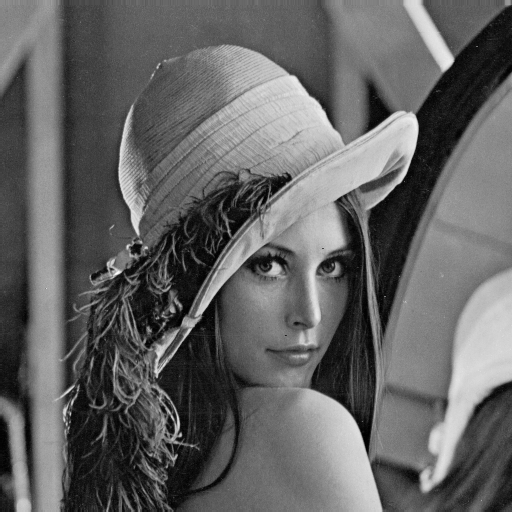

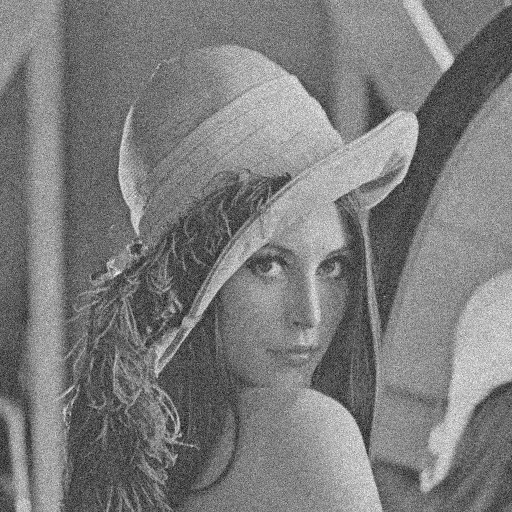

In [6]:
#%%

# voir l'image
viewimage(im,titre='ORIGINALE')
#degrader une image

imb=degrade_image(im,25)

# voir l'image bruitée
viewimage(imb,titre='BRUITEE')



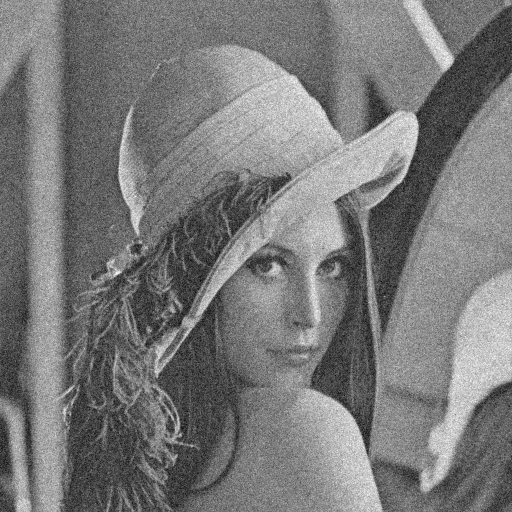

In [7]:
#%% restauration quadratique : exemple
lamb=.1
restau=minimisation_quadratique(imb,lamb)
viewimage(restau,titre='RESTQUAD_LAMB='+str(lamb))



le lambda optimal pour la projection de Chambolle est 39.810717055349734
le lambda optimal pour la descente de gradient est 1.2000000000000002


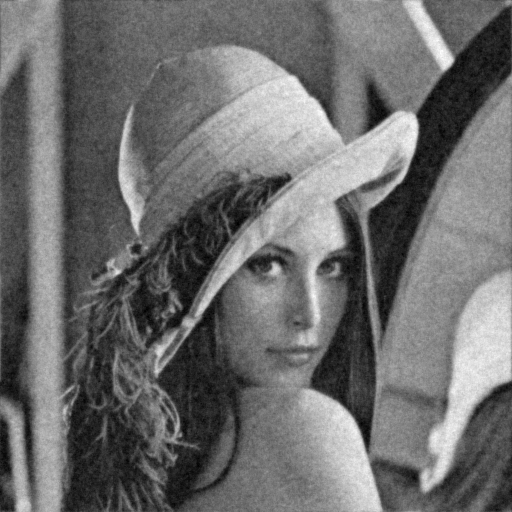

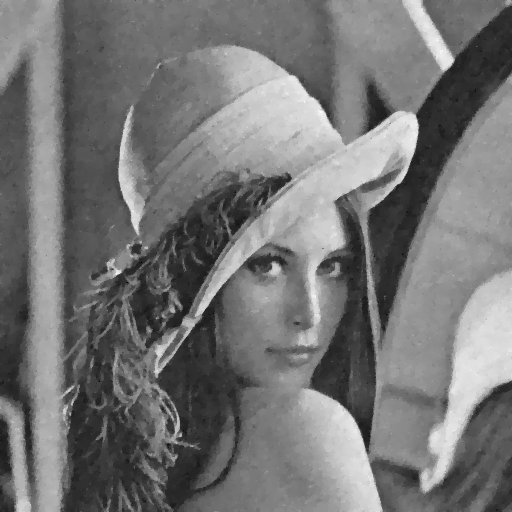

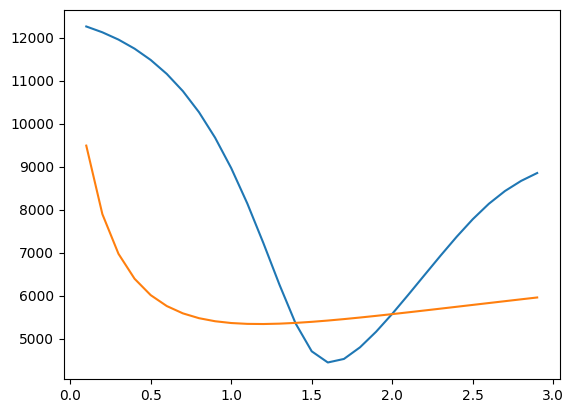

In [18]:
#%% COMPARAISON des methodes
# vous pouvez vous inspirer de ce qui suit pour trouver les meilleurs
# parametres de regularisation

errq=[]
errvt=[]
# erreur=[]
# diff=[]
# vk=np.arange(0,0.5,0.001);
# err1 = norm2(imb - im)
# for k in vk:
#     #print (k)
#     restq=minimisation_quadratique(imb,10^(k));
#     #errq.append(norm2(restq-myim));
#     restva=vartotale_Chambolle(imb,10**(k));
#     restq=minimisation_quadratique(imb,10**(k))
#     err2 = norm2(imb-restq)
#     erreur.append(err2)
#     #
#     #errvt.append(norm2(restva-myim));
#     diff.append(abs(err1 - err2))

# idx_opt = np.argmin(diff)
# lambda_opt = 10**vk[idx_opt]
# print(f"Lambda optimal (erreurs égales) : {lambda_opt}")
# print(f"Erreur1 = {erreur[idx_opt]}, Erreur2 = {err2}")


#plt.plot(10**vk,errvt);
vk=np.arange(0.1,3,0.1)
for k in vk:
    restva=vartotale_Chambolle(imb,10**(k))
    restq=minimisation_quadratique(imb,k)
    errq.append(norm2(im-restq))
    errvt.append(norm2(restva-im))

idx_opt_q = np.argmin(errq)
idx_opt_VT = np.argmin(errvt)
lambda_opt_q = vk[idx_opt_q]
lambda_opt_vt = 10**vk[idx_opt_VT]
print(f'le lambda optimal pour la projection de Chambolle est {lambda_opt_vt}')
print(f'le lambda optimal pour la descente de gradient est {lambda_opt_q}')
plt.plot(vk, errvt)
plt.plot(vk, errq)

viewimage(minimisation_quadratique(imb,lambda_opt_q))
viewimage(vartotale_Chambolle(imb, lambda_opt_vt))


In [11]:
#%%
u1,en1=minimise_TV_gradient(imb, 40, 1, 20)
u05,en05=minimise_TV_gradient(imb, 40, 0.5, 20)
u01,en01=minimise_TV_gradient(imb, 40, 0.1, 20)
#u05inf,en05inf=minimise_TV_gradient(imb, 10, 0.5, 200)


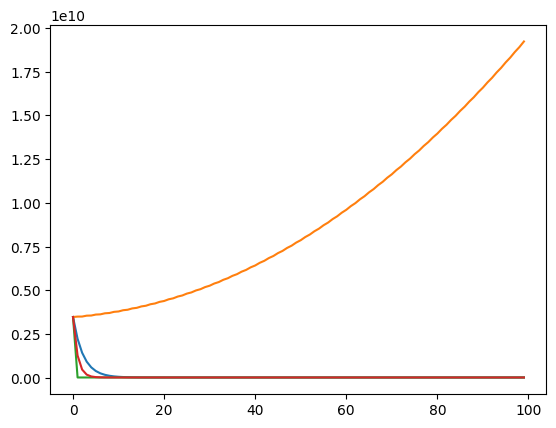

In [12]:
#%%
myim=imread('lena.tif')
imb=degrade_image(myim,25)
(u,energ)=minimise_TV_gradient(imb,1,0.1,100)   # pas = 0.1
(u,energ2)=minimise_TV_gradient(imb,1,1,100)       # pas = 1
(u,energ3)=minimise_TV_gradient(imb,1,0.5,100)       # pas = 0.5
(u,energ4)=minimise_TV_gradient(imb,1,0.8,100)         # pas de 1

plt.plot(energ)
plt.plot(energ2)
plt.plot(energ3)
plt.plot(energ4)

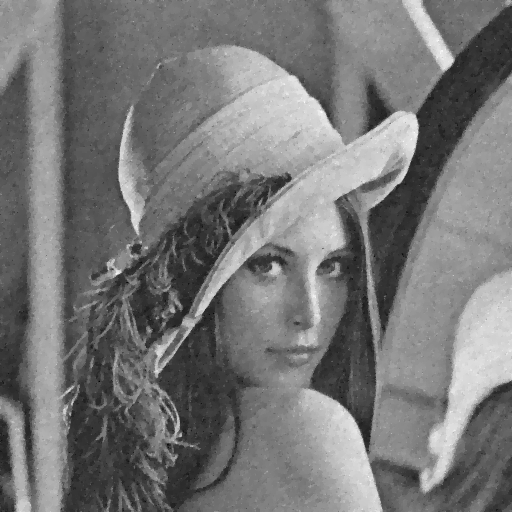

In [13]:
imcha = vartotale_Chambolle(imb, 32, 100)
viewimage(imcha)


Lambda optimal trouvé : 1.2690 (k = 0.10)
Erreur minimale : 5325.1845


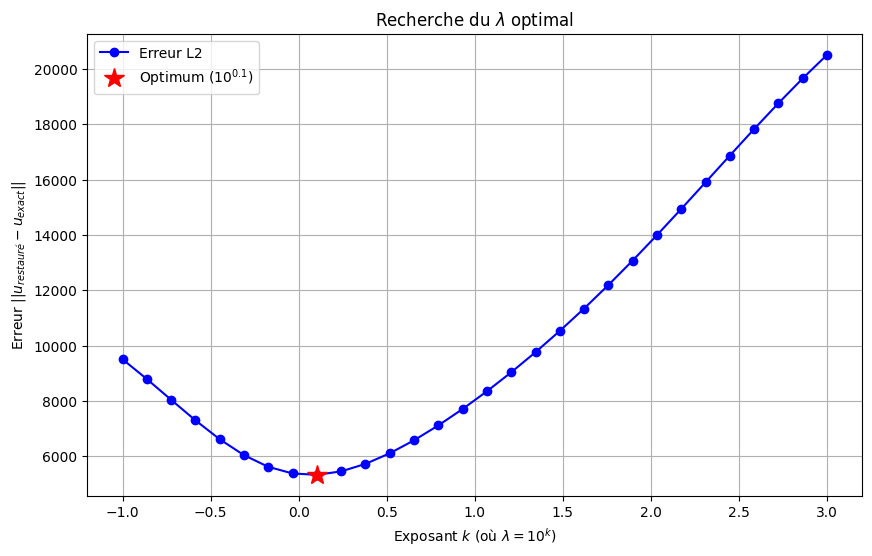

In [ ]:
def trouver_lambda_optimal(image_bruitee, image_parfaite, methode_restauration):
    # On cherche lambda entre 10^-1 et 10^3
    valeurs_k = np.linspace(-1, 3, 30) 
    
    erreurs = []
    
    # 2. Boucle de test
    for k in valeurs_k:
        lam = 10**k
        
        # a. Restauration de l'image avec ce lambda
        # methode_restauration peut être minimisation_quadratique ou vartotale_Chambolle
        u_tilde = methode_restauration(image_bruitee, lam)
        
        # b. Calcul de l'erreur par rapport à la vérité terrain (u)
        # On utilise la norme L2 
        err = norm2(u_tilde - image_parfaite)
        erreurs.append(err)
    
    # 3. Trouver le minimum
    idx_min = np.argmin(erreurs)
    lambda_opt = 10**valeurs_k[idx_min]
    erreur_min = erreurs[idx_min]
    
    return lambda_opt, erreur_min, valeurs_k, erreurs

lam_opt, err_min, k_vals, err_vals = trouver_lambda_optimal(imb, im, minimisation_quadratique)

print(f"Lambda optimal trouvé : {lam_opt:.4f} (k = {np.log10(lam_opt):.2f})")
print(f"Erreur minimale : {err_min:.4f}")

# Création du graphique
plt.figure(figsize=(10, 6))

# On trace l'erreur en fonction de k (l'exposant)
plt.plot(k_vals, err_vals, 'b-o', label='Erreur L2')

# On marque le point optimal en rouge
idx_min = np.argmin(err_vals)
plt.plot(k_vals[idx_min], err_vals[idx_min], 'r*', markersize=15, label=f'Optimum ($10^{{{k_vals[idx_min]:.1f}}}$)')

plt.title(r"Recherche du $\lambda$ optimal")
plt.xlabel(r"Exposant $k$ (où $\lambda = 10^k$)")
plt.ylabel(r"Erreur $||u_{restauré} - u_{exact}||$")
plt.grid(True)
plt.legend()
plt.show()

# Réponses aux Questions 

### Question 1 : 

On cherche à résoudre : $E_1(u) = \|u - v\|^2 + \lambda \|\nabla u\|^2$. 

Pour réaliser cela, `minimisation_quadratique` prépare des filtres finies $K_x = (1, -1)$ et $K_y = (1, -1)^T$. Ces filtres vont permettre d'approcher $\nabla u$, en x et en y, en discrétisant u.  
L'outil `resoud_quad` permet de réoudre le problème quadratique donné par `minimisation_quadratique` en passant par le domaine de fourier notamment avec la fft.  
$$
\begin{aligned}
E_1(u) &= \|u - v\|^2 + \lambda \|\nabla u\|^2 \\
&= \|u - v\|^2 + \lambda \sum_{i,j} \left((K_x \ast u)^2(i,j) + (K_y \ast u)^2(i,j)\right)
\end{aligned}
$$
On a donc : $K_0 = \delta \quad K_1 = \sqrt{\lambda}K_x \quad K_2 = \sqrt{\lambda}K_y $   
On passe dasn le domaine de Fourier : 
$$\hat{E_1} = \sum_c \sum_w |\hat{K_c}(w)\hat{u}(w) - \hat{V_c}(x)|$$

## Question 2 :  
- Lorsque $\lambda$ est très petit, l'image n'est presque pas débruitée. En effet, le terme de régularisation va devenir négligeable et l'algorithme va privilégier ce qui reste collé aux données. L'image u sera donc très proche de l'image bruitée v.
- Lorsque $\lambda$ est très grand par contre, l'image va avoir tendance à se lisser grandement. Le terme de régularisation va devenir plus important, ce qui va pénaliser les contours de l'image. L'image sera débruitée mais très floue.

## Question 3 : 
On trouve que le $\lambda$ optimal pour que $ \|\tilde{u} - v\|^2 \sim \|u - v\|^2 $ est environ égale à $3, 3$.

## Question 4 : 
Pour trouver le $\lambda$ optimal, l'algorithme est simple, on applique la méthode pour une grande plage de $\lambda$, on calcule l'erreur entre l'image parfaite et reconstruite que l'on stock dans une liste. On trouve ensuite l'indice dont l'argument est le minimum pour calculer le $\lambda$.  
En traçant $err = f(\lambda)$ on trouve que la courbe fait une parabole. Pour un $\lambda$ trop faible l'erreur augmente (car le bruit n'a pas été enlevé), pour un trop important l'erreur augmente aussi (car l'image reconstruite est floue).
